In [1]:
#impot libraries and packeges
import io
import os
import cv2 
import PIL.Image
import pytesseract
import numpy as np
from pytesseract import Output
from matplotlib import pyplot as plt
from IPython.display import clear_output, Image, display

In [2]:
#defining the image path
pytesseract.pytesseract.tesseract_cmd = 'C:/Program Files/Tesseract-OCR/tesseract.exe'
IMG_DIR = 'dataset/'

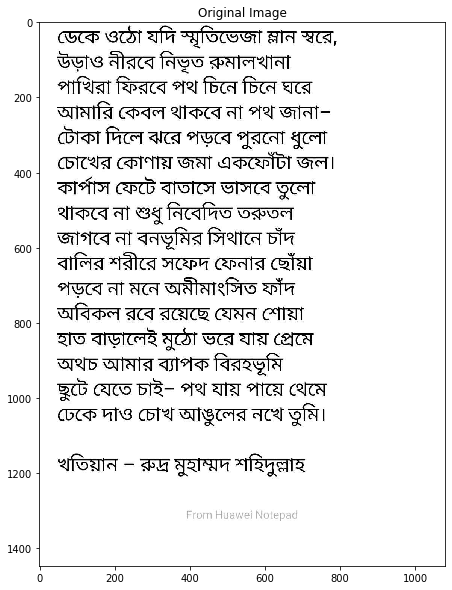

In [3]:
#taking input
image = cv2.imread(IMG_DIR + '1.jpg')

plt.figure(figsize=(10,10))
plt.title('Original Image')
plt.imshow(image)
plt.show()

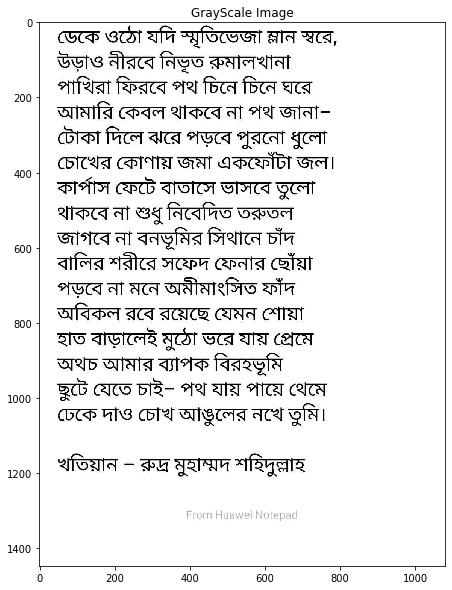

In [4]:
#applying greyscale filter
gray_scale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,10))
plt.title('GrayScale Image')
plt.imshow(gray_scale_image, cmap='gray')
plt.show()

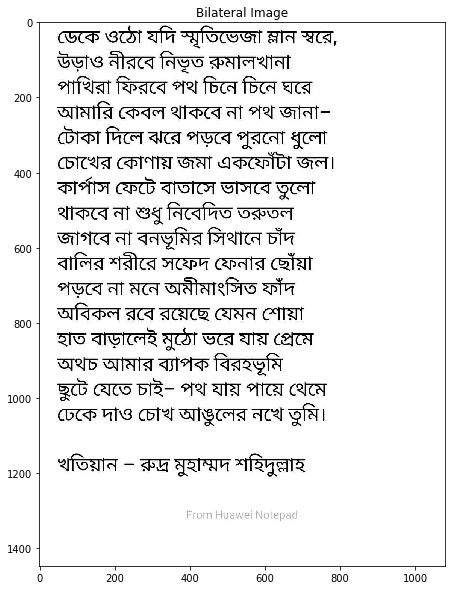

In [5]:
#applying bilateral filter
bilateral_image = cv2.bilateralFilter(gray_scale_image, 15, 75, 75)

plt.figure(figsize=(10,10))
plt.title('Bilateral Image')
plt.imshow(gray_scale_image, cmap='gray')
plt.show()

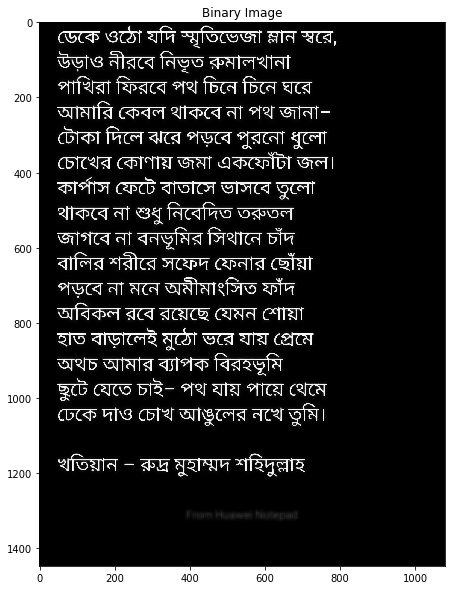

In [6]:
#applying bit plane slicing or getting binary image
binary_image = cv2.bitwise_not(bilateral_image)

plt.figure(figsize=(10,10))
plt.title('Binary Image')
plt.imshow(binary_image, cmap='gray')
plt.show()

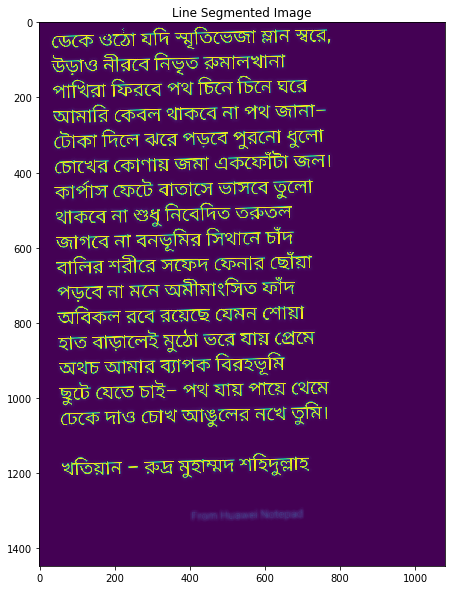

In [7]:
#applying skew angle correction

thresh = cv2.threshold(binary_image, 0, 255,
	cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
coords = np.column_stack(np.where(thresh > 0))
angle = cv2.minAreaRect(coords)[-1]
if angle < -45:
	angle = -(90 + angle)
else:
	angle = -angle
(h, w) = binary_image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_image = cv2.warpAffine(binary_image, M, (w, h),
	flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
cv2.putText(rotated_image, "Angle: {:.2f} degrees".format(angle),
	(10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

plt.figure(figsize=(10,10))
plt.title('Line Segmented Image')
plt.imshow(rotated_image)
plt.show()

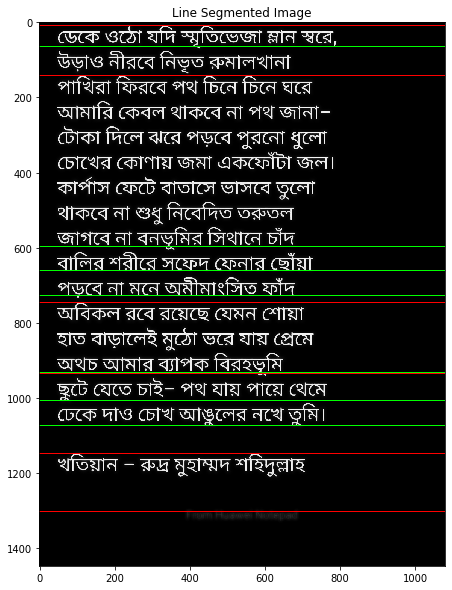

In [8]:
hist = cv2.reduce(binary_image,1, cv2.REDUCE_AVG).reshape(-1)

th = 2
H,W = gray_scale_image.shape[:2]
uppers = [y for y in range(H-1) if hist[y]<=th and hist[y+1]>th]
lowers = [y for y in range(H-1) if hist[y]>th and hist[y+1]<=th]

binary_image = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2BGR)
for y in uppers:
    cv2.line(binary_image, (0,y), (W, y), (255,0,0), 1)

for y in lowers:
    cv2.line(binary_image, (0,y), (W, y), (0,255,0), 1)
    
plt.figure(figsize=(10,10))
plt.title('Line Segmented Image')
plt.imshow(binary_image)
plt.show()

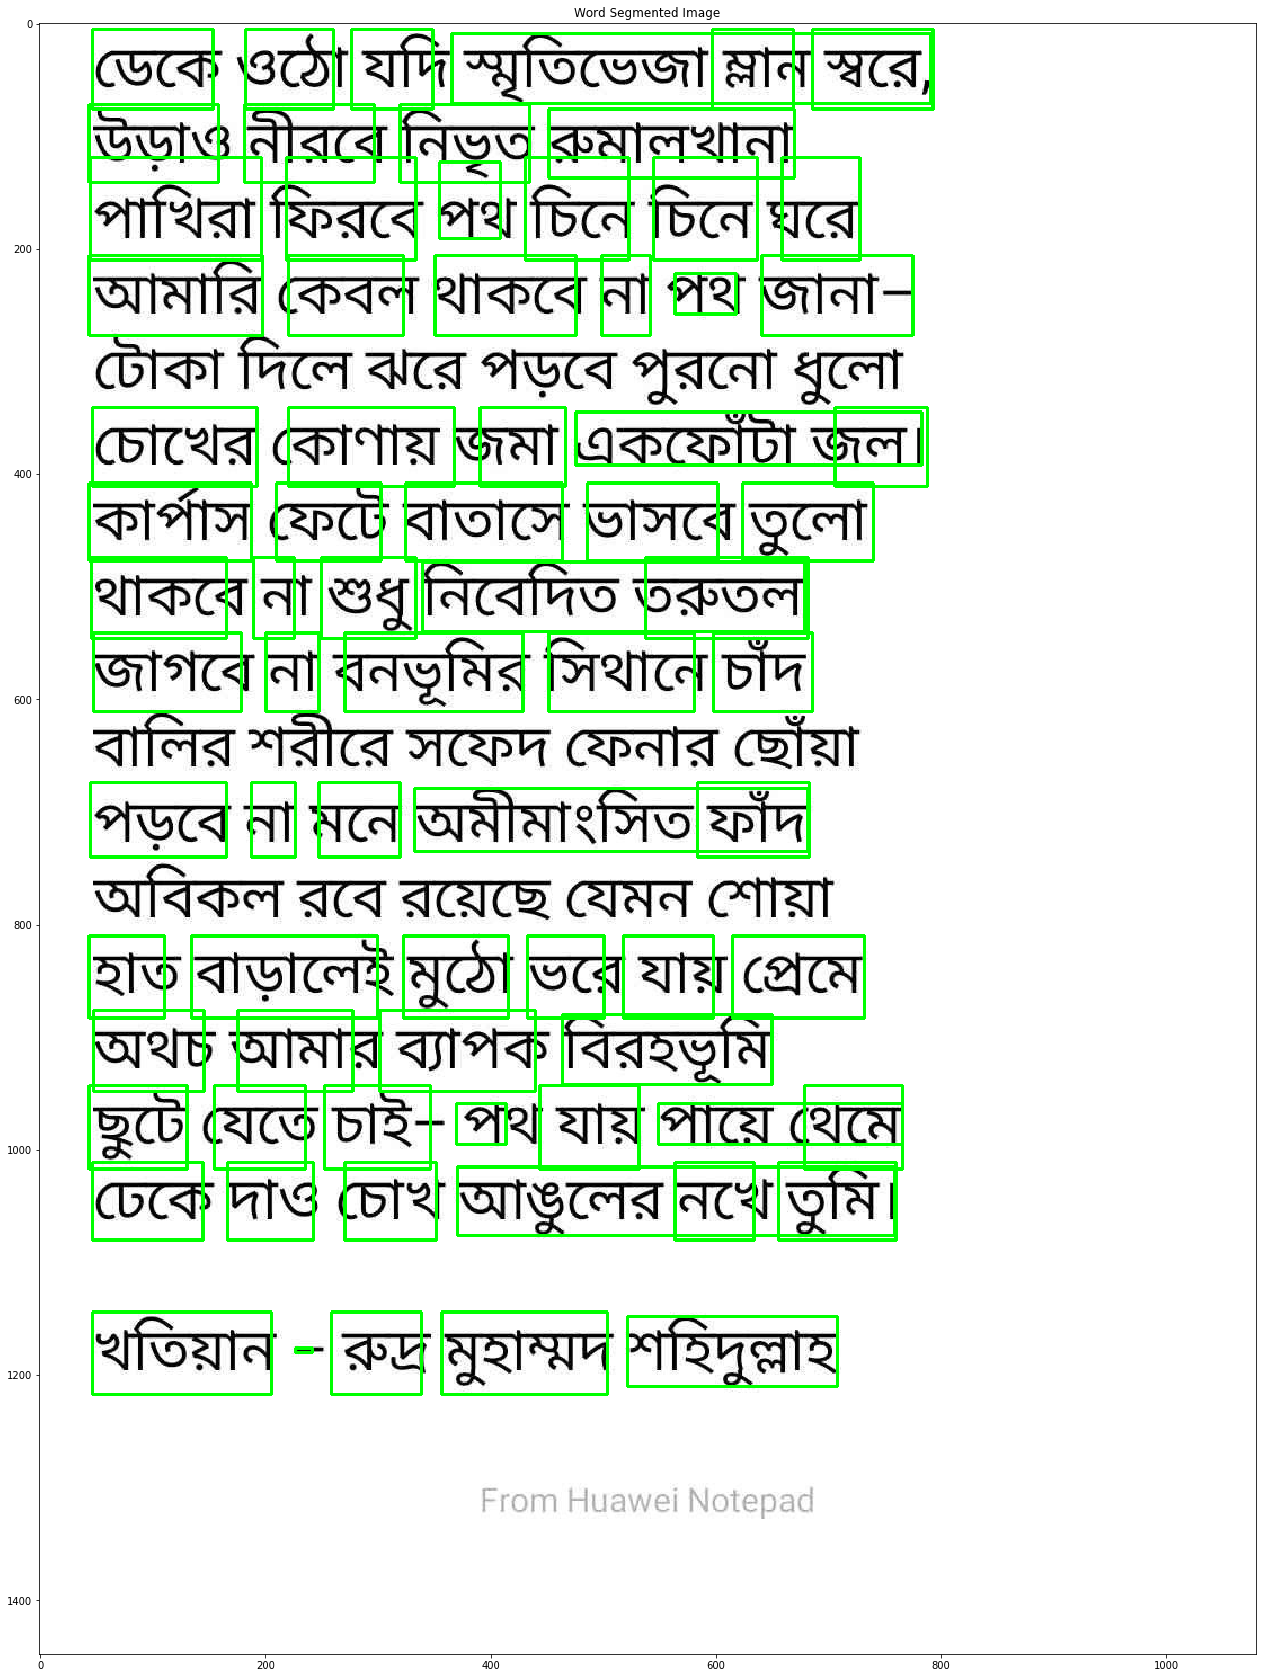

In [9]:
hist = cv2.reduce(rotated_image,1, cv2.REDUCE_AVG).reshape(-1)

th = 2
H,W = image.shape[:2]
uppers = [x for x in range(H-1) if hist[x]<=th and hist[x+1]>th]
lowers = [x for x in range(H-1) if hist[x]>th and hist[x+1]<=th]
d = pytesseract.image_to_data(gray_scale_image, output_type=Output.DICT,lang="ben")
image = cv2.imread(IMG_DIR + '1.jpg')
n_boxes = len(d['text'])
for i in range(n_boxes):
    if int(d['conf'][i]) > 0:
        (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
        image = cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

b,g,r = cv2.split(image)
rgb_img = cv2.merge([r,g,b])
plt.figure(figsize=(30,30))
plt.imshow(rgb_img)
plt.title('Word Segmented Image')
plt.show()

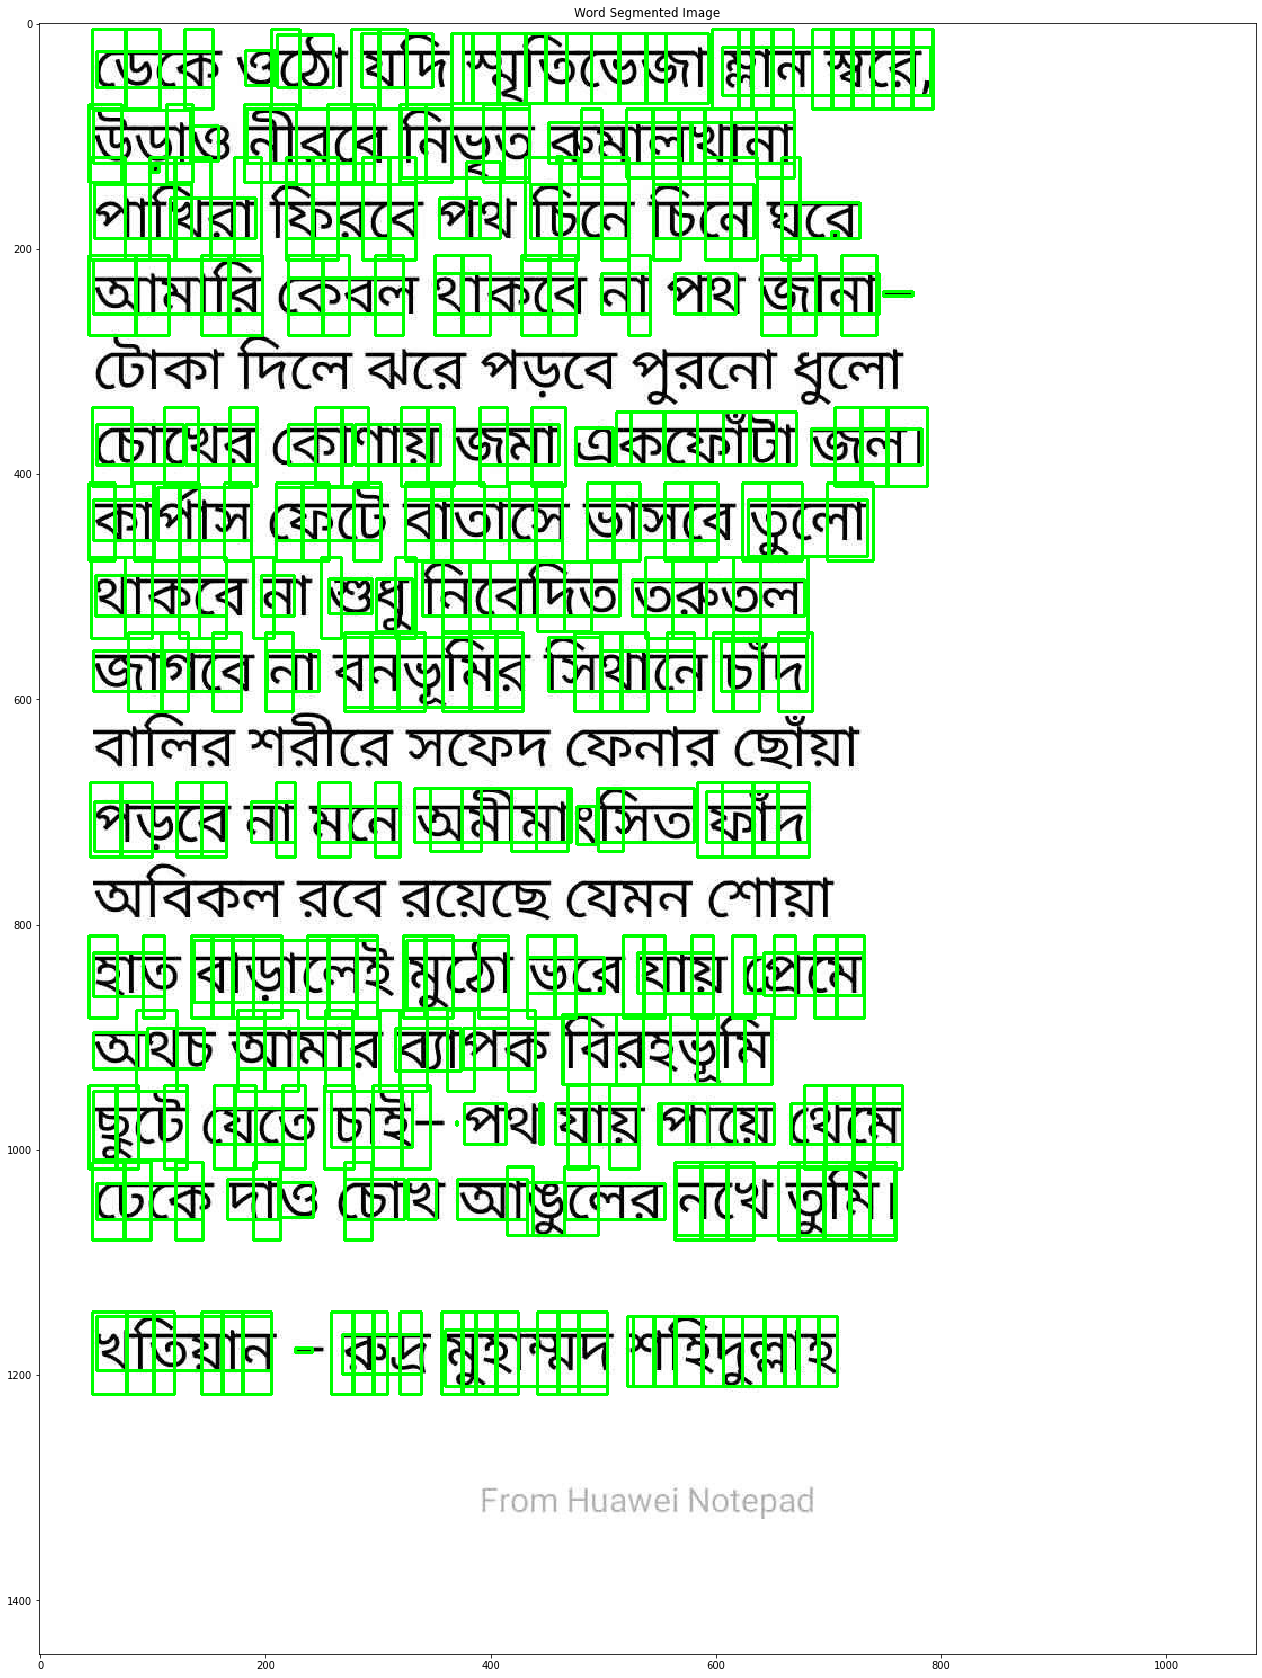


!!!! Extracted Text !!!!

ডেকে ওঠো যদি স্মৃতিভেজা ললান স্বরে,
উড়াও নীরবে নিভৃত রুমালখানা
পাখিরা ফিরবে পথ চিনে চিনে ঘরে
আমারি কেবল থাকবে না পথ জানা-
চোখের কোণায় জমা একফোঁটা জল।
কার্পাস ফেটে বাতাসে ভাসবে তুলো
থাকবে না শুধু নিবেদিত তরুতল
জাগবে না বনভূমির সিথানে চাঁদ
পড়বে না মনে অমীমাংসিত ফাঁদ
হাত বাড়ালেই মুঠো ভরে যায় প্রেমে
অথচ আমার ব্যাপক বিরহভূমি

ছুটে যেতে চাই- পথ যায় পায়ে থেমে
ঢেকে দাও চোখ আঙুলের নখে তুমি।

খতিয়ান - রুদ্র মুহাম্মদ শহিদুল্লাহ


In [12]:
image = cv2.imread(IMG_DIR + '1.jpg')
h, w, c = image.shape
boxes = pytesseract.image_to_boxes(image,lang="ben") 
for b in boxes.splitlines():
    b = b.split(' ')
    image = cv2.rectangle(image, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2)
b,g,r = cv2.split(image)
rgb_img = cv2.merge([r,g,b])
plt.figure(figsize=(30,30))
plt.imshow(rgb_img)
plt.title('Word Segmented Image')
plt.show()
print("\n!!!! Extracted Text !!!!\n")
text = pytesseract.image_to_string(gray_scale_image,lang="ben")
print (text)